# 11a — Cross-Validation Pipeline & Feature Selection

This notebook implements leakage-safe feature selection and 5-fold stratified cross-validation using the integrated demographic + questionnaire dataset produced by the multimodal data integration stage.

## Objective

The notebook:

- loads `data/processed/demographics_questionnaire.csv`;
- excludes participant identifiers and diagnosis-derived variables from predictors;
- implements reproducible 5-fold stratified cross-validation;
- fits preprocessing **only on each training fold**;
- performs feature selection **inside each training fold**;
- applies the fitted preprocessing and selected feature set to the corresponding validation fold;
- evaluates fold-level performance using a class-weighted multinomial Logistic Regression model;
- exports selected features for every fold;
- exports selected training and validation feature datasets for every fold;
- produces a feature-selection stability summary;
- produces fold-level and aggregate performance summaries;
- verifies participant separation and confirms that validation information is not used during preprocessing or feature selection.

All generated results are written to the existing project output structure under `outputs/metrics`, `outputs/tables`, and `outputs/figures`.

## 1. Libraries and project paths

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 150)

# Locate the project root whether the notebook is executed from
# the repository root or from the notebooks directory.
cwd = Path.cwd().resolve()

if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the src directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for directory in [METRICS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATA_FILE = PROCESSED_DIR / "demographics_questionnaire.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Input dataset: {DATA_FILE}")
print(f"Metrics directory: {METRICS_DIR}")
print(f"Tables directory: {TABLES_DIR}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease
Input dataset: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\data\processed\demographics_questionnaire.csv
Metrics directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\metrics
Tables directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\tables
Figures directory: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\figures


## 2. Cross-validation and feature-selection configuration

In [2]:
RANDOM_STATE = 42
N_SPLITS = 5
N_SELECTED_FEATURES = 20
TARGET_COLUMN = "label"
PARTICIPANT_ID_COLUMN = "patient_id"

# Columns excluded from modeling because they are identifiers
# or diagnosis-derived variables that could cause leakage.
EXCLUDED_COLUMNS = [
    PARTICIPANT_ID_COLUMN,
    TARGET_COLUMN,
    "condition_group",
]

print(f"Cross-validation folds: {N_SPLITS}")
print(f"Requested selected features per fold: {N_SELECTED_FEATURES}")
print(f"Random state: {RANDOM_STATE}")

Cross-validation folds: 5
Requested selected features per fold: 20
Random state: 42


The number of selected features is fixed across folds to allow direct comparison of feature-selection stability. Selection is performed after fold-specific preprocessing using an ANOVA F-test (`SelectKBest(f_classif)`). A zero-variance filter is applied first so features with no variability in a training fold cannot be selected.

## 3. Load the demographic + questionnaire dataset

In [3]:
assert DATA_FILE.exists(), (
    f"Dataset not found: {DATA_FILE}\n"
    "Run the multimodal data integration notebook first."
)

data = pd.read_csv(
    DATA_FILE,
    dtype={PARTICIPANT_ID_COLUMN: str},
)

print(f"Dataset shape: {data.shape}")
print(
    f"Unique participants: "
    f"{data[PARTICIPANT_ID_COLUMN].nunique():,}"
)
display(data.head())

Dataset shape: (469, 53)
Unique participants: 469


,patient_id,condition_group,label,age,age_at_diagnosis,height_cm,weight_kg,gender,handedness,family_history_any,family_history_first_degree,alcohol_effect_on_tremor,Q01,Q02,Q03,Q04,Q05,Q06,Q07,Q08,Q09,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,Q29,Q30,total_symptom_count,gastrointestinal_count,urinal_count,pain_count,miscellaneous_count,apathy_attention_memory_count,distortion_perception_count,depression_anxiety_count,sexual_function_count,cardiovascular_count,sleep_fatigue_count
0,1,Healthy Control,0,56.0,NaN,173.0,78.0,Male,Right,Yes,Yes,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Other Movement Disorder,2,81.0,69.0,193.0,104.0,Male,Right,No,Unknown,No Effect,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,12.0,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,3.0,3.0
2,3,Healthy Control,0,45.0,NaN,170.0,78.0,Female,Right,No,Unknown,Unknown,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Parkinson's Disease,1,67.0,63.0,161.0,90.0,Female,Right,No,Unknown,No Effect,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,12.0,1.0,2.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,3.0
4,5,Parkinson's Disease,1,75.0,65.0,172.0,86.0,Male,Left,No,Unknown,Unknown,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,11.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,5.0


The integrated dataset contains one participant-level record per row and combines demographic variables with questionnaire-derived features. The target is `label`; `patient_id` is retained only for split auditing and output traceability.

## 4. Dataset validation

In [4]:
required_columns = {
    PARTICIPANT_ID_COLUMN,
    TARGET_COLUMN,
}

missing_required = required_columns.difference(data.columns)

assert not missing_required, (
    f"Missing required columns: {sorted(missing_required)}"
)

assert data[PARTICIPANT_ID_COLUMN].notna().all(), (
    "Missing participant identifiers detected."
)

duplicate_participants = data[
    data[PARTICIPANT_ID_COLUMN].duplicated(keep=False)
]

assert duplicate_participants.empty, (
    "Duplicate participant rows detected. Because this dataset should "
    "contain one row per participant, duplicates must be resolved before "
    "using StratifiedKFold."
)

assert data[TARGET_COLUMN].notna().all(), (
    "Missing target labels detected."
)

print("Dataset validation: PASS")
print(f"Rows: {len(data):,}")
print(
    f"Unique participants: "
    f"{data[PARTICIPANT_ID_COLUMN].nunique():,}"
)

print("\nClass distribution:")
display(
    data[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

Dataset validation: PASS
Rows: 469
Unique participants: 469

Class distribution:


,count
label,
0,79
1,276
2,114


## 5. Define predictors and target

In [5]:
feature_columns = [
    column
    for column in data.columns
    if column not in EXCLUDED_COLUMNS
]

X = data[feature_columns].copy()
y = data[TARGET_COLUMN].copy()
participant_ids = data[PARTICIPANT_ID_COLUMN].copy()

print(f"Raw predictor count: {X.shape[1]}")
print(f"Target classes: {sorted(y.unique().tolist())}")

print("\nExcluded columns:")
print(EXCLUDED_COLUMNS)

print("\nPredictor columns:")
print(feature_columns)

Raw predictor count: 50
Target classes: [0, 1, 2]

Excluded columns:
['patient_id', 'label', 'condition_group']

Predictor columns:
['age', 'age_at_diagnosis', 'height_cm', 'weight_kg', 'gender', 'handedness', 'family_history_any', 'family_history_first_degree', 'alcohol_effect_on_tremor', 'Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07', 'Q08', 'Q09', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'total_symptom_count', 'gastrointestinal_count', 'urinal_count', 'pain_count', 'miscellaneous_count', 'apathy_attention_memory_count', 'distortion_perception_count', 'depression_anxiety_count', 'sexual_function_count', 'cardiovascular_count', 'sleep_fatigue_count']


`condition_group` is excluded because it is diagnosis-derived and therefore directly related to the target. `patient_id` is excluded from model fitting but retained separately so participant overlap can be checked for every fold.

## 6. Identify numerical and categorical predictors

In [6]:
numerical_features = (
    X.select_dtypes(include=["number"])
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(exclude=["number"])
    .columns
    .tolist()
)

feature_type_summary = pd.DataFrame({
    "feature_type": ["numerical", "categorical"],
    "count": [
        len(numerical_features),
        len(categorical_features),
    ],
})

display(feature_type_summary)

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

,feature_type,count
0,numerical,45
1,categorical,5



Numerical features:
['age', 'age_at_diagnosis', 'height_cm', 'weight_kg', 'Q01', 'Q02', 'Q03', 'Q04', 'Q05', 'Q06', 'Q07', 'Q08', 'Q09', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30', 'total_symptom_count', 'gastrointestinal_count', 'urinal_count', 'pain_count', 'miscellaneous_count', 'apathy_attention_memory_count', 'distortion_perception_count', 'depression_anxiety_count', 'sexual_function_count', 'cardiovascular_count', 'sleep_fatigue_count']

Categorical features:
['gender', 'handedness', 'family_history_any', 'family_history_first_degree', 'alcohol_effect_on_tremor']


## 7. Build fold-specific preprocessing

In [7]:
def build_preprocessor(
    numerical_columns,
    categorical_columns,
):
    """Create a fresh preprocessing transformer for one CV fold."""

    numerical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median"),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent"),
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
            ),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "numerical",
                numerical_pipeline,
                numerical_columns,
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_columns,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

A new preprocessor is created and fitted for each cross-validation fold. Numerical imputation medians, categorical imputation modes, scaling parameters, and one-hot encoding categories are therefore learned exclusively from the training portion of that fold.

## 8. Initialize stratified cross-validation

In [8]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


Stratification maintains the class-label distribution across folds. Because the input dataset contains exactly one row per participant, standard stratified cross-validation also maintains participant independence between the training and validation subsets.

## 9. Run leakage-safe cross-validation and feature selection

In [12]:
fold_metrics = []
selected_feature_records = []
fold_audit_records = []
fold_assignment_records = []
out_of_fold_predictions = []

for fold_number, (train_index, validation_index) in enumerate(
    cv.split(X, y),
    start=1,
):
    # ----------------------------------------------------------
    # Partition raw participant-level data
    # ----------------------------------------------------------
    X_train = X.iloc[train_index].copy()
    X_validation = X.iloc[validation_index].copy()

    y_train = y.iloc[train_index].copy()
    y_validation = y.iloc[validation_index].copy()

    train_ids = participant_ids.iloc[train_index].copy()
    validation_ids = participant_ids.iloc[validation_index].copy()

    # Explicit participant-level leakage check.
    participant_overlap = (
        set(train_ids)
        .intersection(set(validation_ids))
    )

    assert not participant_overlap, (
        f"Participant overlap detected in fold {fold_number}: "
        f"{sorted(participant_overlap)}"
    )

    # ----------------------------------------------------------
    # Fresh preprocessing + selection + classifier for this fold
    # ----------------------------------------------------------
    preprocessor = build_preprocessor(
        numerical_features,
        categorical_features,
    )

    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor,
            ),
            (
                "variance_filter",
                VarianceThreshold(threshold=0.0),
            ),
            (
                "feature_selection",
                SelectKBest(
                    score_func=f_classif,
                    k=N_SELECTED_FEATURES,
                ),
            ),
            (
                "classifier",
                LogisticRegression(
                    solver="lbfgs",
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    # IMPORTANT:
    # fit() receives TRAINING-FOLD data only.
    # The validation fold is untouched until prediction/transform.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pipeline.fit(
            X_train,
            y_train,
        )

    validation_predictions = pipeline.predict(
        X_validation
    )

    # ----------------------------------------------------------
    # Fold-level performance
    # ----------------------------------------------------------
    metrics = {
        "fold": fold_number,
        "train_participants": len(train_index),
        "validation_participants": len(validation_index),
        "accuracy": accuracy_score(
            y_validation,
            validation_predictions,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_validation,
            validation_predictions,
        ),
        "macro_f1": f1_score(
            y_validation,
            validation_predictions,
            average="macro",
            zero_division=0,
        ),
        "precision_macro": precision_score(
            y_validation,
            validation_predictions,
            average="macro",
            zero_division=0,
        ),
        "recall_macro": recall_score(
            y_validation,
            validation_predictions,
            average="macro",
            zero_division=0,
        ),
    }

    fold_metrics.append(metrics)

    # ----------------------------------------------------------
    # Recover selected transformed feature names
    # ----------------------------------------------------------
    preprocessing_step = pipeline.named_steps[
        "preprocessing"
    ]

    transformed_feature_names = (
        preprocessing_step
        .get_feature_names_out()
    )

    variance_step = pipeline.named_steps[
        "variance_filter"
    ]

    variance_feature_names = (
        transformed_feature_names[
            variance_step.get_support()
        ]
    )

    selection_step = pipeline.named_steps[
        "feature_selection"
    ]

    selected_feature_names = (
        variance_feature_names[
            selection_step.get_support()
        ]
    )

    selected_scores = (
        selection_step.scores_[
            selection_step.get_support()
        ]
    )

    assert len(selected_feature_names) == N_SELECTED_FEATURES

    # ----------------------------------------------------------
    # Record selected features
    # ----------------------------------------------------------
    fold_selected_table = pd.DataFrame({
        "fold": fold_number,
        "feature": selected_feature_names,
        "selection_score": selected_scores,
    }).sort_values(
        "selection_score",
        ascending=False,
    )

    fold_selected_table.to_csv(
        TABLES_DIR
        / f"cv_fold_{fold_number}_selected_features.csv",
        index=False,
    )

    selected_feature_records.extend(
        fold_selected_table.to_dict("records")
    )

    # ----------------------------------------------------------
    # Export selected train/validation feature datasets
    # using ONLY the fold-fitted preprocessing + selector.
    # ----------------------------------------------------------
    X_train_preprocessed = (
        preprocessing_step.transform(X_train)
    )

    X_validation_preprocessed = (
        preprocessing_step.transform(X_validation)
    )

    X_train_variance = variance_step.transform(
        X_train_preprocessed
    )

    X_validation_variance = variance_step.transform(
        X_validation_preprocessed
    )

    X_train_selected = selection_step.transform(
        X_train_variance
    )

    X_validation_selected = selection_step.transform(
        X_validation_variance
    )

    train_selected_df = pd.DataFrame(
        X_train_selected,
        columns=selected_feature_names,
    )

    train_selected_df.insert(
        0,
        TARGET_COLUMN,
        y_train.reset_index(drop=True),
    )

    train_selected_df.insert(
        0,
        PARTICIPANT_ID_COLUMN,
        train_ids.reset_index(drop=True),
    )

    validation_selected_df = pd.DataFrame(
        X_validation_selected,
        columns=selected_feature_names,
    )

    validation_selected_df.insert(
        0,
        TARGET_COLUMN,
        y_validation.reset_index(drop=True),
    )

    validation_selected_df.insert(
        0,
        PARTICIPANT_ID_COLUMN,
        validation_ids.reset_index(drop=True),
    )

    train_selected_df.to_csv(
        TABLES_DIR
        / f"cv_fold_{fold_number}_selected_train_dataset.csv",
        index=False,
    )

    validation_selected_df.to_csv(
        TABLES_DIR
        / f"cv_fold_{fold_number}_selected_validation_dataset.csv",
        index=False,
    )

    # ----------------------------------------------------------
    # Leakage audit
    # ----------------------------------------------------------
    fold_audit_records.append({
        "fold": fold_number,
        "train_participants": train_ids.nunique(),
        "validation_participants": validation_ids.nunique(),
        "participant_overlap_count": len(participant_overlap),
        "preprocessing_fit_scope": "training_fold_only",
        "feature_selection_fit_scope": "training_fold_only",
        "selected_feature_count": len(selected_feature_names),
        "leakage_check": "PASS",
    })

    # Save fold membership for reproducibility.
    for participant_id in train_ids:
        fold_assignment_records.append({
            PARTICIPANT_ID_COLUMN: participant_id,
            "fold": fold_number,
            "role": "train",
        })

    for participant_id in validation_ids:
        fold_assignment_records.append({
            PARTICIPANT_ID_COLUMN: participant_id,
            "fold": fold_number,
            "role": "validation",
        })

    # Out-of-fold predictions for optional aggregate checks.
    out_of_fold_predictions.extend(
        pd.DataFrame({
            PARTICIPANT_ID_COLUMN:
                validation_ids.reset_index(drop=True),
            "fold": fold_number,
            "y_true":
                y_validation.reset_index(drop=True),
            "y_pred":
                validation_predictions,
        }).to_dict("records")
    )

    print(
        f"Fold {fold_number}: "
        f"train={len(train_index)}, "
        f"validation={len(validation_index)}, "
        f"selected={len(selected_feature_names)}, "
        f"macro_f1={metrics['macro_f1']:.3f}"
    )

Fold 1: train=375, validation=94, selected=20, macro_f1=0.511
Fold 2: train=375, validation=94, selected=20, macro_f1=0.613
Fold 3: train=375, validation=94, selected=20, macro_f1=0.598
Fold 4: train=375, validation=94, selected=20, macro_f1=0.545
Fold 5: train=376, validation=93, selected=20, macro_f1=0.602


The validation subset is not supplied to `.fit()` at any stage. Preprocessing statistics, encoded categories, zero-variance filtering, ANOVA feature scores, selected feature indices, and classifier coefficients are all estimated from the corresponding training fold only. The fitted transformations are then applied to that fold's validation data.

## 10. Fold-level performance summary

In [13]:
fold_performance = pd.DataFrame(
    fold_metrics
)

display(fold_performance)

fold_performance.to_csv(
    METRICS_DIR
    / "cv_fold_performance.csv",
    index=False,
)

,fold,train_participants,validation_participants,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
0,1,375,94,0.563830,0.521624,0.511298,0.508452,0.521624
1,2,375,94,0.659574,0.652125,0.613226,0.601111,0.652125
2,3,375,94,0.648936,0.646064,0.597976,0.611072,0.646064
3,4,375,94,0.595745,0.581981,0.545038,0.529923,0.581981
4,5,376,93,0.645161,0.634168,0.601801,0.588696,0.634168


In [14]:
metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "precision_macro",
    "recall_macro",
]

cv_performance_summary = pd.DataFrame({
    "metric": metric_columns,
    "mean": [
        fold_performance[column].mean()
        for column in metric_columns
    ],
    "std": [
        fold_performance[column].std(ddof=1)
        for column in metric_columns
    ],
    "min": [
        fold_performance[column].min()
        for column in metric_columns
    ],
    "max": [
        fold_performance[column].max()
        for column in metric_columns
    ],
})

display(cv_performance_summary)

cv_performance_summary.to_csv(
    METRICS_DIR
    / "cv_performance_summary.csv",
    index=False,
)

,metric,mean,std,min,max
0,accuracy,0.622649,0.041064,0.563830,0.659574
1,balanced_accuracy,0.607192,0.055261,0.521624,0.652125
2,macro_f1,0.573868,0.043751,0.511298,0.613226
3,precision_macro,0.567851,0.045759,0.508452,0.611072
4,recall_macro,0.607192,0.055261,0.521624,0.652125


## 11. Selected features by fold

In [15]:
selected_features_by_fold = pd.DataFrame(
    selected_feature_records
)

display(
    selected_features_by_fold
    .sort_values(
        ["fold", "selection_score"],
        ascending=[True, False],
    )
)

selected_features_by_fold.to_csv(
    TABLES_DIR
    / "cv_selected_features_all_folds.csv",
    index=False,
)

,fold,feature,selection_score
0,1,total_symptom_count,62.525091
1,1,Q02,43.026297
2,1,urinal_count,38.645356
3,1,distortion_perception_count,38.561978
4,1,gastrointestinal_count,32.349632
5,1,Q08,29.822015
6,1,sleep_fatigue_count,28.901740
7,1,apathy_attention_memory_count,26.690026
8,1,Q25,25.941681
9,1,Q01,21.732146


## 12. Feature-selection stability summary

In [17]:
feature_selection_summary = (
    selected_features_by_fold
    .groupby("feature")
    .agg(
        times_selected=("fold", "nunique"),
        mean_selection_score=("selection_score", "mean"),
        std_selection_score=("selection_score", "std"),
    )
    .reset_index()
)

feature_selection_summary[
    "selection_percentage"
] = (
    feature_selection_summary[
        "times_selected"
    ]
    / N_SPLITS
    * 100
)

feature_selection_summary = (
    feature_selection_summary
    .sort_values(
        [
            "times_selected",
            "mean_selection_score",
        ],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(feature_selection_summary)

feature_selection_summary.to_csv(
    TABLES_DIR
    / "cv_feature_selection_summary.csv",
    index=False,
)

,feature,times_selected,mean_selection_score,std_selection_score,selection_percentage
0,total_symptom_count,5,59.278942,2.726661,100.0
1,urinal_count,5,41.030428,3.314723,100.0
2,Q02,5,35.651207,5.311133,100.0
3,distortion_perception_count,5,35.404472,2.649660,100.0
4,gastrointestinal_count,5,32.970272,0.526206,100.0
5,Q08,5,31.937391,2.166805,100.0
6,sleep_fatigue_count,5,30.795619,2.699535,100.0
7,Q25,5,28.319928,2.064799,100.0
8,cardiovascular_count,5,21.485083,1.940068,100.0
9,Q01,5,21.392905,0.411188,100.0


Features selected repeatedly across folds are more stable under resampling. The `times_selected` and `selection_percentage` fields quantify selection stability, while the mean selection score summarizes the average univariate discrimination observed when the feature was selected.

## 13. Leakage verification and fold audit

In [18]:
fold_audit = pd.DataFrame(
    fold_audit_records
)

display(fold_audit)

assert (
    fold_audit["participant_overlap_count"]
    .eq(0)
    .all()
)

assert (
    fold_audit["leakage_check"]
    .eq("PASS")
    .all()
)

assert (
    fold_audit["feature_selection_fit_scope"]
    .eq("training_fold_only")
    .all()
)

fold_audit.to_csv(
    TABLES_DIR
    / "cv_feature_selection_leakage_audit.csv",
    index=False,
)

print(
    "Leakage verification: PASS — "
    "preprocessing and feature selection were fit "
    "using training-fold data only."
)

,fold,train_participants,validation_participants,participant_overlap_count,preprocessing_fit_scope,feature_selection_fit_scope,selected_feature_count,leakage_check
0,1,375,94,0,training_fold_only,training_fold_only,20,PASS
1,2,375,94,0,training_fold_only,training_fold_only,20,PASS
2,3,375,94,0,training_fold_only,training_fold_only,20,PASS
3,4,375,94,0,training_fold_only,training_fold_only,20,PASS
4,5,376,93,0,training_fold_only,training_fold_only,20,PASS


Leakage verification: PASS — preprocessing and feature selection were fit using training-fold data only.


In [19]:
fold_assignments = pd.DataFrame(
    fold_assignment_records
)

fold_assignments.to_csv(
    TABLES_DIR
    / "cv_fold_assignments.csv",
    index=False,
)

# Every participant must serve as validation exactly once.
validation_counts = (
    fold_assignments[
        fold_assignments["role"] == "validation"
    ]
    [PARTICIPANT_ID_COLUMN]
    .value_counts()
)

assert validation_counts.eq(1).all()
assert len(validation_counts) == len(data)

print(
    "Fold assignment verification: PASS — "
    "every participant appears in validation exactly once."
)

Fold assignment verification: PASS — every participant appears in validation exactly once.


## 14. Out-of-fold prediction summary

In [20]:
oof_predictions = pd.DataFrame(
    out_of_fold_predictions
)

assert (
    oof_predictions[PARTICIPANT_ID_COLUMN]
    .nunique()
    == len(data)
)

oof_metrics = pd.DataFrame(
    [{
        "accuracy": accuracy_score(
            oof_predictions["y_true"],
            oof_predictions["y_pred"],
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                oof_predictions["y_true"],
                oof_predictions["y_pred"],
            ),
        "macro_f1": f1_score(
            oof_predictions["y_true"],
            oof_predictions["y_pred"],
            average="macro",
            zero_division=0,
        ),
        "precision_macro": precision_score(
            oof_predictions["y_true"],
            oof_predictions["y_pred"],
            average="macro",
            zero_division=0,
        ),
        "recall_macro": recall_score(
            oof_predictions["y_true"],
            oof_predictions["y_pred"],
            average="macro",
            zero_division=0,
        ),
    }]
)

display(oof_metrics)

oof_predictions.to_csv(
    TABLES_DIR
    / "cv_out_of_fold_predictions.csv",
    index=False,
)

oof_metrics.to_csv(
    METRICS_DIR
    / "cv_out_of_fold_metrics.csv",
    index=False,
)

,accuracy,balanced_accuracy,macro_f1,precision_macro,recall_macro
0,0.622601,0.607577,0.572707,0.561864,0.607577


## 15. Feature-selection stability figure

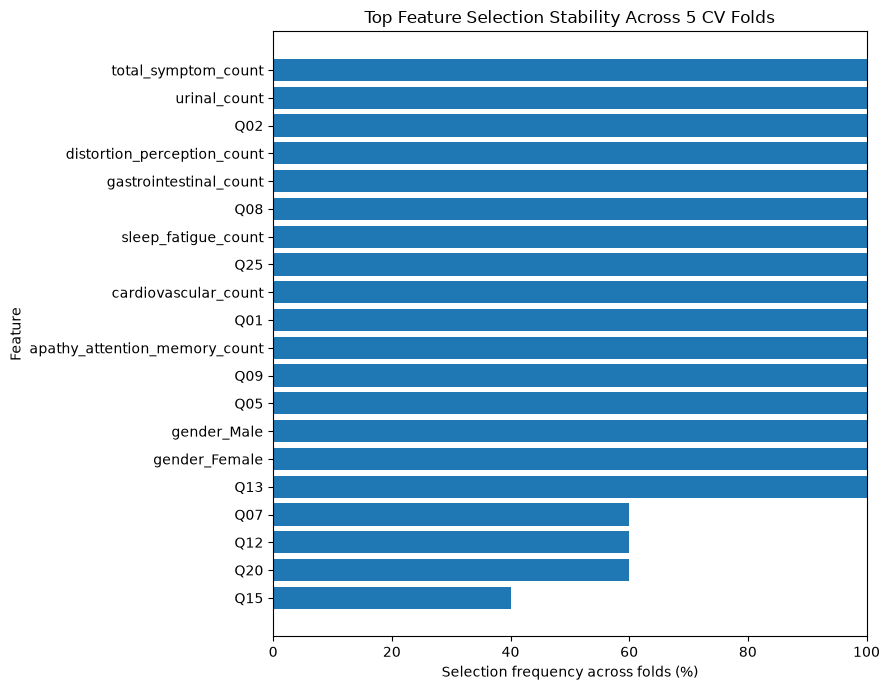

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\figures\cv_feature_selection_stability.png


In [21]:
stable_features = (
    feature_selection_summary
    .head(20)
    .sort_values(
        [
            "times_selected",
            "mean_selection_score",
        ],
        ascending=[True, True],
    )
)

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.barh(
    stable_features["feature"],
    stable_features["selection_percentage"],
)

ax.set_xlabel(
    "Selection frequency across folds (%)"
)

ax.set_ylabel("Feature")

ax.set_title(
    "Top Feature Selection Stability Across 5 CV Folds"
)

ax.set_xlim(0, 100)

fig.tight_layout()

figure_path = (
    FIGURES_DIR
    / "cv_feature_selection_stability.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {figure_path}")

## 16. Fold performance figure

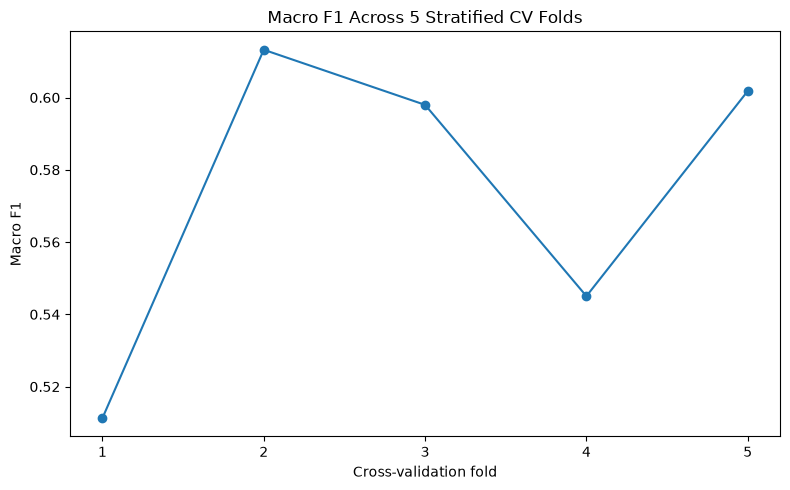

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\figures\cv_fold_macro_f1.png


In [22]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    fold_performance["fold"],
    fold_performance["macro_f1"],
    marker="o",
)

ax.set_xlabel("Cross-validation fold")
ax.set_ylabel("Macro F1")
ax.set_title(
    "Macro F1 Across 5 Stratified CV Folds"
)
ax.set_xticks(
    fold_performance["fold"]
)

fig.tight_layout()

figure_path = (
    FIGURES_DIR
    / "cv_fold_macro_f1.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {figure_path}")

## 17. Aggregate confusion matrix

,Pred_0,Pred_1,Pred_2
True_0,59,8,12
True_1,27,188,61
True_2,37,32,45


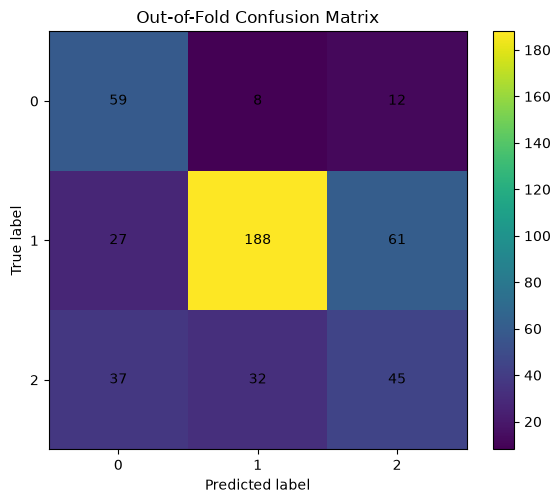

Saved: C:\Users\Daniela\Documents\UNF\Summer 2026-Term 5\AI-Assisted-Screening-of-Parkinson-s-Disease\outputs\figures\cv_out_of_fold_confusion_matrix.png


In [23]:
class_labels = sorted(
    data[TARGET_COLUMN].unique().tolist()
)

aggregate_confusion = confusion_matrix(
    oof_predictions["y_true"],
    oof_predictions["y_pred"],
    labels=class_labels,
)

aggregate_confusion_df = pd.DataFrame(
    aggregate_confusion,
    index=[
        f"True_{label}"
        for label in class_labels
    ],
    columns=[
        f"Pred_{label}"
        for label in class_labels
    ],
)

display(aggregate_confusion_df)

aggregate_confusion_df.to_csv(
    METRICS_DIR
    / "cv_out_of_fold_confusion_matrix.csv",
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(
    aggregate_confusion
)

fig.colorbar(image, ax=ax)

ax.set_title(
    "Out-of-Fold Confusion Matrix"
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks(
    range(len(class_labels))
)
ax.set_yticks(
    range(len(class_labels))
)

ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)

for i in range(
    aggregate_confusion.shape[0]
):
    for j in range(
        aggregate_confusion.shape[1]
    ):
        ax.text(
            j,
            i,
            aggregate_confusion[i, j],
            ha="center",
            va="center",
        )

fig.tight_layout()

figure_path = (
    FIGURES_DIR
    / "cv_out_of_fold_confusion_matrix.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved: {figure_path}")

## 18. Deliverables verification

In [24]:
deliverables = pd.DataFrame({
    "deliverable": [
        "5-fold stratified cross-validation pipeline",
        "Feature selection within each training fold",
        "Selected feature list for each fold",
        "Selected training feature dataset for each fold",
        "Selected validation feature dataset for each fold",
        "Feature selection summary",
        "Fold performance summary",
        "Leakage verification audit",
        "Out-of-fold predictions and metrics",
        "Feature-selection stability figure",
        "Fold macro-F1 figure",
        "Out-of-fold confusion matrix",
    ],
    "location": [
        "Notebook",
        "Notebook",
        "outputs/tables/cv_fold_*_selected_features.csv",
        "outputs/tables/cv_fold_*_selected_train_dataset.csv",
        "outputs/tables/cv_fold_*_selected_validation_dataset.csv",
        "outputs/tables/cv_feature_selection_summary.csv",
        "outputs/metrics/cv_fold_performance.csv and cv_performance_summary.csv",
        "outputs/tables/cv_feature_selection_leakage_audit.csv",
        "outputs/tables/cv_out_of_fold_predictions.csv and outputs/metrics/cv_out_of_fold_metrics.csv",
        "outputs/figures/cv_feature_selection_stability.png",
        "outputs/figures/cv_fold_macro_f1.png",
        "outputs/metrics/cv_out_of_fold_confusion_matrix.csv and outputs/figures/cv_out_of_fold_confusion_matrix.png",
    ],
    "status": ["READY"] * 12,
})

deliverables

,deliverable,location,status
0,5-fold stratified cross-validation pipeline,Notebook,READY
1,Feature selection within each training fold,Notebook,READY
2,Selected feature list for each fold,outputs/tables/cv_fold_*_selected_features.csv,READY
3,Selected training feature dataset for each fold,outputs/tables/cv_fold_*_selected_train_datase...,READY
4,Selected validation feature dataset for each fold,outputs/tables/cv_fold_*_selected_validation_d...,READY
5,Feature selection summary,outputs/tables/cv_feature_selection_summary.csv,READY
6,Fold performance summary,outputs/metrics/cv_fold_performance.csv and cv...,READY
7,Leakage verification audit,outputs/tables/cv_feature_selection_leakage_au...,READY
8,Out-of-fold predictions and metrics,outputs/tables/cv_out_of_fold_predictions.csv ...,READY
9,Feature-selection stability figure,outputs/figures/cv_feature_selection_stability...,READY


## 19. Initial observations

In [25]:
best_fold = (
    fold_performance
    .sort_values(
        "macro_f1",
        ascending=False,
    )
    .iloc[0]
)

most_stable = (
    feature_selection_summary[
        feature_selection_summary[
            "times_selected"
        ]
        == N_SPLITS
    ]
    ["feature"]
    .tolist()
)

print("CROSS-VALIDATION SUMMARY")
print("-" * 50)

print(
    "Mean macro F1: "
    f"{fold_performance['macro_f1'].mean():.3f} "
    "± "
    f"{fold_performance['macro_f1'].std(ddof=1):.3f}"
)

print(
    "Mean balanced accuracy: "
    f"{fold_performance['balanced_accuracy'].mean():.3f} "
    "± "
    f"{fold_performance['balanced_accuracy'].std(ddof=1):.3f}"
)

print(
    f"Best fold by macro F1: "
    f"Fold {int(best_fold['fold'])} "
    f"({best_fold['macro_f1']:.3f})"
)

print(
    "Features selected in all five folds: "
    f"{len(most_stable)}"
)

if most_stable:
    print(most_stable)

print(
    "\nInterpret fold-to-fold variability together with "
    "feature-selection stability before treating any individual "
    "feature as consistently predictive."
)

CROSS-VALIDATION SUMMARY
--------------------------------------------------
Mean macro F1: 0.574 ± 0.044
Mean balanced accuracy: 0.607 ± 0.055
Best fold by macro F1: Fold 2 (0.613)
Features selected in all five folds: 16
['total_symptom_count', 'urinal_count', 'Q02', 'distortion_perception_count', 'gastrointestinal_count', 'Q08', 'sleep_fatigue_count', 'Q25', 'cardiovascular_count', 'Q01', 'apathy_attention_memory_count', 'Q09', 'Q05', 'gender_Male', 'gender_Female', 'Q13']

Interpret fold-to-fold variability together with feature-selection stability before treating any individual feature as consistently predictive.


## 20. Conclusion

This notebook implements a reproducible five-fold stratified cross-validation workflow with leakage-safe feature selection. Every fold constructs and fits a new preprocessing pipeline, zero-variance filter, ANOVA feature selector, and class-weighted Logistic Regression classifier using the training portion only. The fitted transformations and selected feature set are then applied to the held-out validation portion.

The exported fold-specific feature datasets, selected-feature lists, feature-selection stability summary, leakage audit, and fold-performance summaries provide the required artifacts for downstream model development and technical reporting. Because every participant appears in the validation set exactly once, the out-of-fold predictions also provide an aggregate estimate of performance across the complete demographic + questionnaire dataset without fitting feature selection on validation observations.